# Creating Custom Layers and Models

#### Step 1: Import the necessary libraries

In [4]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
from tensorflow.keras.models import Sequential

#### Step 2: Define a custom layer

In [5]:
class CustomDenseLayer(Layer):
  def __init__(self, unit=32):
    super(CustomDenseLayer, self).__init__()
    self.unit = unit

  def build(self, input_shape):
    self.w = self.add_weight(shape=(input_shape[-1], self.unit), initializer='random_normal', trainable=True)
    self.b = self.add_weight(shape=(self.unit,), initializer='zeros', trainable=True)

  def call(self, inputs):
    return tf.nn.relu(tf.matmul(inputs, self.w) + self.b)

#### Step 3: Integrate custom layer into model

In [6]:
from tensorflow.keras.layers import Softmax

# Define the model with Softmax in the output layer
model = Sequential([
  CustomDenseLayer(128),
  CustomDenseLayer(10), # Hidden layer
  Softmax() # Output Layer
])

#### Step 4: Compile the model

In [7]:
model.compile(optimizer='adam', loss='categorical_crossentropy')
# Model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_dense_layer              │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer_1            │ ?                      │   0 (unbuilt) │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Build the model
model.build((1000, 20))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_dense_layer              │ (1000, 128)            │         2,688 │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dense_layer_1            │ (1000, 10)             │         1,290 │
│ (CustomDenseLayer)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Softmax)               │ (1000, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,978 (15.54 KB)

 Trainable params: 3,978 (15.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Step 5: Train the model

In [9]:
import numpy as np

# Generate random data
X_train = np.random.random((1000, 20))
y_train = np.random.randint(10, size=(1000, 1))

# Convert the label into categorical one-hot encoding
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 831us/step - loss: 2.3038
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - loss: 2.3004
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 482us/step - loss: 2.2985
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 2.2965
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 447us/step - loss: 2.2944
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 445us/step - loss: 2.2927
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 432us/step - loss: 2.2904
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 446us/step - loss: 2.2879
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 466us/step - loss: 2.2866
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - loss: 2.2848


#### Step 6: Evaluate the model

In [10]:
# Generate the test data
X_test = np.random.random(size=(200, 20))
y_test = np.random.randint(10, size=(200, 1))

# Convert the label into categorical one-hot encoding
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
loss = model.evaluate(X_test, y_test)
print(f"LOSS: {loss}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.3107 
LOSS: 2.3106753826141357


#### Step 7: Visualize the Model Architecture

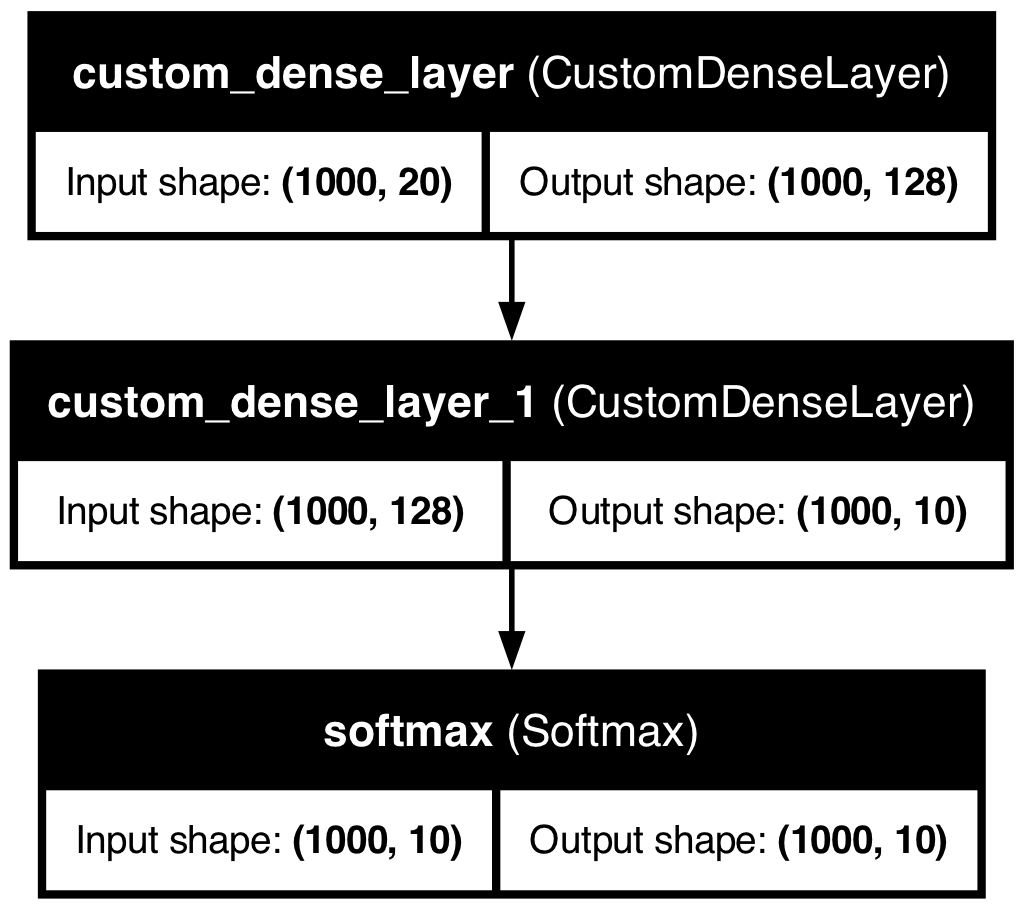

In [11]:
from tensorflow.keras.utils import plot_model
# Visualize the model architecture
plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

#### Step 8: Add the Dropout layer

In [12]:
from tensorflow.keras.layers import Dropout
model_with_dropout_layer = Sequential([
  CustomDenseLayer(128),
  Dropout(rate=0.5),
  CustomDenseLayer(10),
  Softmax()
])

model_with_dropout_layer.compile(optimizer="adam", loss="categorical_crossentropy")
model_with_dropout_layer.fit(X_train, y_train, epochs=10, batch_size=23)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 500us/step - loss: 2.3055 
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 484us/step - loss: 2.3025
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - loss: 2.3030
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - loss: 2.2995
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 450us/step - loss: 2.3002
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 471us/step - loss: 2.3005
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - loss: 2.2994
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - loss: 2.2984
Epoch 9/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 496us/step - loss: 2.2985
Epoch 10/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 458us/step - loss: 2.2959
